<a href="https://colab.research.google.com/github/michalejan/EEG-Neural-Representation-Prediciton-Model_BA/blob/main/LDA_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Pipeline using the LDA technique for EEG data classification on the Kuo & Prat (2023) data set.

## 1. Environment setup & loading

In [1]:
!pip install -q mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 35.6 MB/s eta 0:00:00


In [2]:
import mne
import numpy as np
import os
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
target_dir = "/content/drive/MyDrive/EEG_data/Preprocessing_results/all_subs/epochs_fifs"
test_subject_file = "sub-001_cleaned_epo.fif"
file_path = os.path.join(target_dir, test_subject_file)
print(f"\n--- LOADING DATA FOR {test_subject_file} ---")
epochs = mne.read_epochs(file_path, preload=True)


--- LOADING DATA FOR sub-001_cleaned_epo.fif ---
Reading /content/drive/MyDrive/EEG_data/Preprocessing_results/all_subs/epochs_fifs/sub-001_cleaned_epo.fif ...
    Found the data of interest:
        t =    -101.56 ...    1199.22 ms
        0 CTF compensation matrices available
Not setting metadata
77 matching events found
No baseline correction applied
0 projection items activated


In [5]:
# VERIFICATION OF THE DATA FOR SUB-001 AS EXAMPLE

print("\n--- DATA CHECK ---")
print(f"Number of total epochs (trials): {len(epochs)}")
print(f"Electrodes (Channels) present: {epochs.ch_names}")
print(f"Time window: {epochs.times[0]}s to {epochs.times[-1]}s")
print(f"Event IDs in this file: {epochs.event_id}")


--- DATA CHECK ---
Number of total epochs (trials): 77
Electrodes (Channels) present: ['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz', 'LIO', 'ROC']
Time window: -0.1015625s to 1.19921875s
Event IDs in this file: {'B1,3,5,13(110)/B17,19,21,29(111)': 4, 'B1,4,6,14(220)/B17,20,22,30(221)': 7, 'B1,3,5,9(115)/B17,19,21,25(116)': 10, 'B1,4,6,10(225)/B17,20,22,26(226)': 16}


## 2. Label Encoding and Data Extraction for the sub-001 first

Now we will bridge the gap between MNE-Python and Scikit-learn. Machine Learning models require two specific variables:


*   $X$ (The Feature Matrix): The actual brainwaves. We will dynamically filter your epochs to only include the centro-parietal channels and the 500-800ms time window, and then extract the raw numerical values
*   $y$ (The Target Vector): The labels. Your event IDs currently have integer codes (4, 10 for Control; 7, 16 for Violation). Machine Learning models prefer binary classifications, so we will convert these to 0 (Control) and 1 (Violation).

In [6]:
# defining the centro-parietal channels (for the P600)
roi_channels = ['CP1', 'CP2', 'CP5', 'CP6', 'P3', 'P4', 'P7', 'P8', 'Pz']
# filtering the epochs (isolating the time window to 500-800ms for P600 analysis)
epochs_roi = epochs.copy().pick(roi_channels).crop(tmin=0.5, tmax=0.8)
# check-up
print("\n--- POST-FILTERING CHECK ---")
print(f"Channels kept: {epochs_roi.ch_names}")
print(f"New time window: {epochs_roi.times[0]:.3f}s to {epochs_roi.times[-1]:.3f}s")


--- POST-FILTERING CHECK ---
Channels kept: ['CP1', 'CP2', 'CP5', 'CP6', 'P3', 'P4', 'P7', 'P8', 'Pz']
New time window: 0.500s to 0.801s


In [7]:
# creating binary labels
control_codes = [4, 10]
violation_codes = [7, 16]
y = []
for event_id in epochs_roi.events[:, 2]:
    if event_id in control_codes:
        y.append(0)
    elif event_id in violation_codes:
        y.append(1)
    else:
        print(f"Warning: Unexpected code {event_id}")

y = np.array(y)

X = epochs_roi.get_data()

print("\n--- MACHINE LEARNING MATRICES ---")
print(f"Shape of X (Features): {X.shape} -> (Trials, Channels, Timepoints)")
print(f"Shape of y (Labels): {y.shape} -> (Trials,)")
print(f"Class distribution: {sum(y==0)} Control, {sum(y==1)} Violation")



--- MACHINE LEARNING MATRICES ---
Shape of X (Features): (77, 9, 78) -> (Trials, Channels, Timepoints)
Shape of y (Labels): (77,) -> (Trials,)
Class distribution: 38 Control, 39 Violation


## 3. Vectorizing + Scaling + Classifying

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from mne.decoding import Vectorizer

In [9]:
# defining the ml pipeline:
# a) flattening vectorizer from 3D (Trials x Channels x Timepoints) to 2D (Trials x Features)
# b) Standardazation Scaling (https://medium.com/@punya8147_26846/understanding-feature-scaling-in-machine-learning-fe2ea8933b66)
# c) LDA - classifying/seperating the classes between ctrl and viol

clf = make_pipeline(
    Vectorizer(),
    StandardScaler(),
    LinearDiscriminantAnalysis(solver='svd')
)

# cross-validation; 4-1 train-test ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- LDA PIPELINE RESULTS FOR SUB-001 ---")
# combining the pipelines
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print(f"Accuracy for each of the 5 test folds: {scores}")
print(f"Mean Classification Accuracy: {scores.mean() * 100:.2f}%")




--- LDA PIPELINE RESULTS FOR SUB-001 ---
Accuracy for each of the 5 test folds: [0.5        0.5625     0.66666667 0.46666667 0.46666667]
Mean Classification Accuracy: 53.25%


## 4. Group-level Generlization for all 44 subs

In [10]:
import os
import mne
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from mne.decoding import Vectorizer

In [17]:
# downloading the fif files
target_dir = "/content/drive/MyDrive/EEG_data/Preprocessing_results/all_subs/epochs_fifs"
fif_files = [f for f in os.listdir(target_dir) if f.endswith('.fif')]

print(f"Found {len(fif_files)} subjects.")

# defining the parameters
roi_channels = ['CP1', 'CP2', 'CP5', 'CP6', 'P3', 'P4', 'P7', 'P8', 'Pz']


Found 44 subjects.


In [35]:
# repeating the pipeline for all subs
clf = make_pipeline(
    Vectorizer(),
    StandardScaler(),
    LinearDiscriminantAnalysis(solver='svd')
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# dictionary to store the subs' accuracies
subject_accuracies = {}

for filename in fif_files:
    subject_id = filename.split('_')[0] # Extracts 'sub-001'
    file_path = os.path.join(target_dir, filename)

    try:
        epochs = mne.read_epochs(file_path, preload=True, verbose=False)
        # ROI and time window
        epochs_roi = epochs.copy().pick(roi_channels).crop(tmin=0.5, tmax=0.8)

        # ---> THE MISSING PIECE: DYNAMICALLY FIND EVENT CODES FOR THIS SPECIFIC SUBJECT <---
        control_codes = [code for name, code in epochs_roi.event_id.items() if '(110)' in name or '(115)' in name]
        violation_codes = [code for name, code in epochs_roi.event_id.items() if '(220)' in name or '(225)' in name]
        valid_codes = control_codes + violation_codes
        # -----------------------------------------------------------------------------------

        # --- THE FIX: FILTER OUT UNWANTED TRIALS FIRST ---
        valid_indices = np.isin(epochs_roi.events[:, 2], valid_codes)

        # Apply the mask to the epochs object
        epochs_filtered = epochs_roi[valid_indices]

        # create labels
        y = []
        for event_id in epochs_filtered.events[:, 2]:
            if event_id in control_codes:
                y.append(0)
            elif event_id in violation_codes:
                y.append(1)
        y = np.array(y)

        # check for any errors in label seperation
        if len(np.unique(y)) < 2:
            print(f"⚠️ {subject_id} skipped: Missing one of the condition labels.")
            continue

        X = epochs_filtered.get_data()
        scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

        # FINAL REPORT ON ACC
        subject_accuracies[subject_id] = scores.mean()
        print(f"✅ {subject_id} processed | accuracy: {scores.mean() * 100:.1f}%")

    except Exception as e:
        print(f"❌ Error processing {subject_id}: {e}")


all_scores = list(subject_accuracies.values())
group_mean = np.mean(all_scores) * 100
group_std = np.std(all_scores) * 100

print("\n" + "="*40)
print("------ FINAL GROUP-LEVEL LDA RESULTS -----")
print("="*40)
print(f"Total Subjects Successfully Processed: {len(all_scores)}")
print(f"\nGroup Mean Accuracy: {group_mean:.2f}% ± {group_std:.2f}%\n")
print(f"Highest Subject Accuracy: {max(all_scores)*100:.2f}%")
print(f"Lowest Subject Accuracy: {min(all_scores)*100:.2f}%")

✅ sub-004 processed | accuracy: 50.7%
✅ sub-012 processed | accuracy: 60.3%
✅ sub-011 processed | accuracy: 50.0%
✅ sub-001 processed | accuracy: 53.2%
✅ sub-003 processed | accuracy: 36.7%
✅ sub-005 processed | accuracy: 59.4%
✅ sub-010 processed | accuracy: 58.9%
✅ sub-008 processed | accuracy: 55.0%
✅ sub-006 processed | accuracy: 46.6%
✅ sub-002 processed | accuracy: 46.0%
✅ sub-015 processed | accuracy: 48.3%
✅ sub-013 processed | accuracy: 55.7%
✅ sub-014 processed | accuracy: 64.5%
✅ sub-016 processed | accuracy: 59.4%
✅ sub-020 processed | accuracy: 40.7%
✅ sub-022 processed | accuracy: 52.5%
✅ sub-021 processed | accuracy: 39.5%
✅ sub-017 processed | accuracy: 62.4%
✅ sub-023 processed | accuracy: 49.7%
✅ sub-024 processed | accuracy: 51.2%
✅ sub-027 processed | accuracy: 44.4%
✅ sub-033 processed | accuracy: 41.8%
✅ sub-029 processed | accuracy: 70.9%
✅ sub-032 processed | accuracy: 65.0%
✅ sub-031 processed | accuracy: 46.3%
✅ sub-035 processed | accuracy: 61.8%
✅ sub-036 pr

### Statistical testing

In [36]:
from scipy import stats

# testing whether the model's prediction are above the statistical chance level (50%)
chance_level = 0.50

# Perform a one-sample t-test
t_stat, p_value = stats.ttest_1samp(a=all_scores, popmean=chance_level, alternative='greater')

print("\n--- STATISTICAL SIGNIFICANCE TEST ---")
print(f"Group Mean Accuracy: {np.mean(all_scores) * 100:.2f}%")
print(f"T-statistic: {t_stat:.3f}")
if p_value < 0.001:
    print(f"P-value: < 0.001  *** (Highly Significant)")
else:
    print(f"P-value: {p_value:.4f}")


--- STATISTICAL SIGNIFICANCE TEST ---
Group Mean Accuracy: 53.56%
T-statistic: 2.805
P-value: 0.0038


### Ledoit-Wolf Shrinkage LDA TWEAK

In [24]:
clf = make_pipeline(
    Vectorizer(),
    StandardScaler(),
    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
)
# -------------------------------------------------------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
subject_accuracies_shrunk = {}

for filename in fif_files:
    subject_id = filename.split('_')[0]
    file_path = os.path.join(target_dir, filename)

    try:
        epochs = mne.read_epochs(file_path, preload=True, verbose=False)
        epochs_roi = epochs.copy().pick(roi_channels).crop(tmin=0.5, tmax=0.8)

        # Dynamically find event codes
        control_codes = [code for name, code in epochs_roi.event_id.items() if '(110)' in name or '(115)' in name]
        violation_codes = [code for name, code in epochs_roi.event_id.items() if '(220)' in name or '(225)' in name]
        valid_codes = control_codes + violation_codes

        if not control_codes or not violation_codes:
            continue

        # Filtering
        valid_indices = np.isin(epochs_roi.events[:, 2], valid_codes)
        epochs_filtered = epochs_roi[valid_indices]

        y = []
        for event_id in epochs_filtered.events[:, 2]:
            if event_id in control_codes:
                y.append(0)
            elif event_id in violation_codes:
                y.append(1)
        y = np.array(y)

        if len(np.unique(y)) < 2:
            continue

        X = epochs_filtered.get_data()

        # Run ML
        scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        subject_accuracies_shrunk[subject_id] = scores.mean()
        print(f"✅ {subject_id} processed | Shrunk Accuracy: {scores.mean() * 100:.1f}%")

    except Exception as e:
        pass # Silently skip errors for a cleaner output

# Calculate Final Group Statistics
all_shrunk_scores = list(subject_accuracies_shrunk.values())
group_mean_shrunk = np.mean(all_shrunk_scores) * 100
group_std_shrunk = np.std(all_shrunk_scores) * 100

print("\n" + "="*45)
print("🏆 FINAL RESULTS WITH LEDOIT-WOLF SHRINKAGE 🏆")
print("="*45)
print(f"Total Subjects Successfully Processed: {len(all_shrunk_scores)}")
print(f"New Group Mean Accuracy: {group_mean_shrunk:.2f}% ± {group_std_shrunk:.2f}%")
print(f"Highest Subject Accuracy: {max(all_shrunk_scores)*100:.2f}%")
print(f"Lowest Subject Accuracy: {min(all_shrunk_scores)*100:.2f}%")

✅ sub-004 processed | Shrunk Accuracy: 51.8%
✅ sub-012 processed | Shrunk Accuracy: 56.5%
✅ sub-011 processed | Shrunk Accuracy: 48.8%
✅ sub-001 processed | Shrunk Accuracy: 52.9%
✅ sub-003 processed | Shrunk Accuracy: 36.7%
✅ sub-005 processed | Shrunk Accuracy: 62.0%
✅ sub-010 processed | Shrunk Accuracy: 50.0%
✅ sub-008 processed | Shrunk Accuracy: 55.0%
✅ sub-006 processed | Shrunk Accuracy: 42.6%
✅ sub-002 processed | Shrunk Accuracy: 52.2%
✅ sub-015 processed | Shrunk Accuracy: 49.3%
✅ sub-013 processed | Shrunk Accuracy: 51.7%
✅ sub-014 processed | Shrunk Accuracy: 66.0%
✅ sub-016 processed | Shrunk Accuracy: 50.6%
✅ sub-020 processed | Shrunk Accuracy: 41.9%
✅ sub-022 processed | Shrunk Accuracy: 50.0%
✅ sub-021 processed | Shrunk Accuracy: 36.5%
✅ sub-017 processed | Shrunk Accuracy: 64.8%
✅ sub-023 processed | Shrunk Accuracy: 51.0%
✅ sub-024 processed | Shrunk Accuracy: 46.2%
✅ sub-027 processed | Shrunk Accuracy: 48.5%
✅ sub-033 processed | Shrunk Accuracy: 47.2%
✅ sub-029 

## 5. Confusion Matrix

In [37]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from mne.decoding import Vectorizer

In [38]:
target_dir = "/content/drive/MyDrive/EEG_data/Preprocessing_results/all_subs/epochs_fifs"
fif_files = [f for f in os.listdir(target_dir) if f.endswith('.fif')]


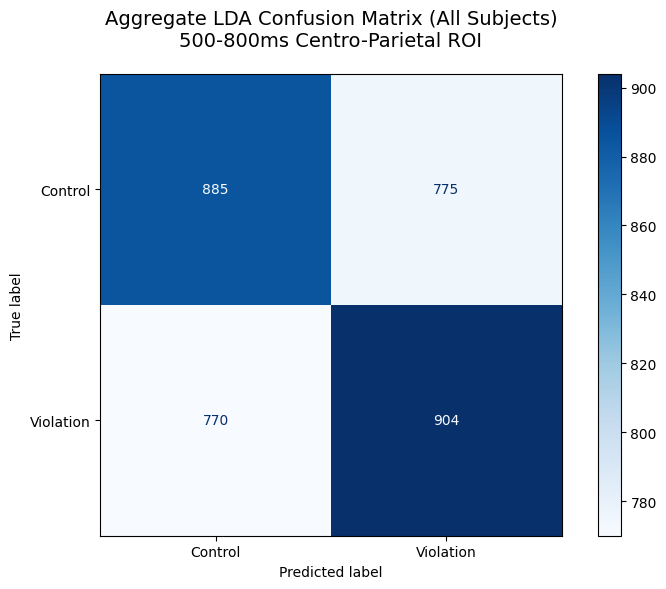

In [39]:
clf = make_pipeline(
    Vectorizer(),
    StandardScaler(),
    LinearDiscriminantAnalysis(solver='svd')
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# an empty 2x2 matrix to add up all predictions
aggregate_cm = np.zeros((2, 2), dtype=int)

for filename in fif_files:
    subject_id = filename.split('_')[0]
    file_path = os.path.join(target_dir, filename)

    try:
        epochs = mne.read_epochs(file_path, preload=True, verbose=False)
        epochs_roi = epochs.copy().pick(roi_channels).crop(tmin=0.5, tmax=0.8)

        control_codes = [code for name, code in epochs_roi.event_id.items() if '(110)' in name or '(115)' in name]
        violation_codes = [code for name, code in epochs_roi.event_id.items() if '(220)' in name or '(225)' in name]
        valid_codes = control_codes + violation_codes

        if not control_codes or not violation_codes:
            continue

        valid_indices = np.isin(epochs_roi.events[:, 2], valid_codes)
        epochs_filtered = epochs_roi[valid_indices]

        y = []
        for event_id in epochs_filtered.events[:, 2]:
            if event_id in control_codes:
                y.append(0)
            elif event_id in violation_codes:
                y.append(1)
        y = np.array(y)

        if len(np.unique(y)) < 2:
            continue

        X = epochs_filtered.get_data()

        # returning an array of 0s and 1s
        y_pred = cross_val_predict(clf, X, y, cv=cv, n_jobs=-1)

        # calculating the confusion matrix
        subject_cm = confusion_matrix(y, y_pred, labels=[0, 1])
        aggregate_cm += subject_cm

    except Exception as e:
        pass

fig, ax = plt.subplots(figsize=(8, 6))
# matrix formatting details
disp = ConfusionMatrixDisplay(confusion_matrix=aggregate_cm, display_labels=['Control', 'Violation'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Aggregate LDA Confusion Matrix (All Subjects)\n500-800ms Centro-Parietal ROI', pad=20, fontsize=14)
plt.tight_layout()
plt.savefig('Group_Confusion_Matrix.png', dpi=300) # Saves a high-res image for your thesis!
plt.show()

## 6. Other Visuals; Subject-Level Accuracy Plot

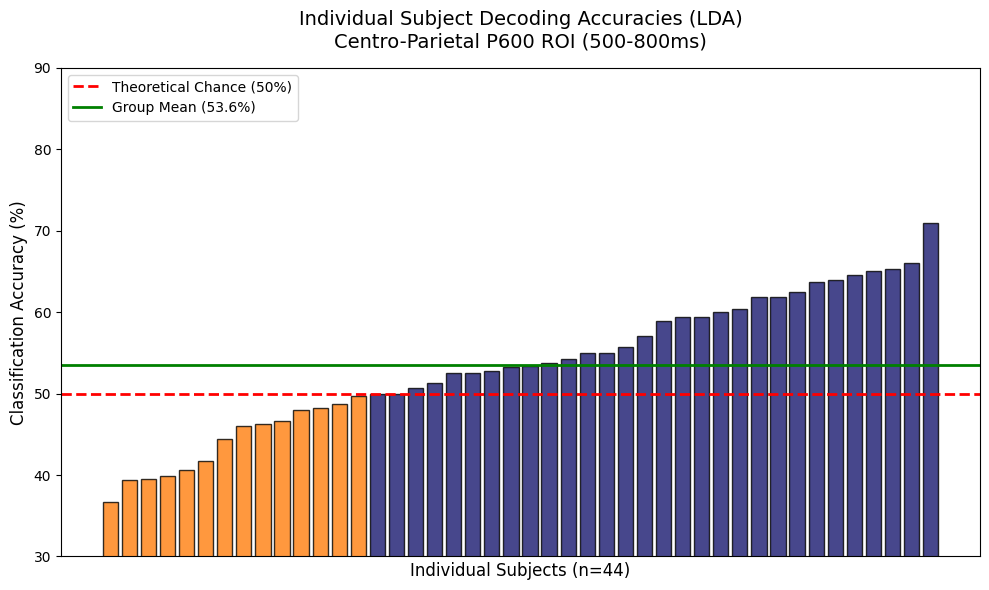

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# sorting the dictionary from lowest to highest
sorted_subs = sorted(subject_accuracies.items(), key=lambda x: x[1])
subjects = [item[0] for item in sorted_subs]
accuracies = [item[1] * 100 for item in sorted_subs]

plt.figure(figsize=(10, 6))

# creating the bars
colors = ['midnightblue' if acc >= 50 else '#ff7f0e' for acc in accuracies]
bars = plt.bar(range(len(subjects)), accuracies, color=colors, edgecolor='black', alpha=0.8)

# reference lines
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Theoretical Chance (50%)')

group_mean = np.mean(accuracies)
plt.axhline(y=group_mean, color='green', linestyle='-', linewidth=2, label=f'Group Mean ({group_mean:.1f}%)')

# formatting
plt.title('Individual Subject Decoding Accuracies (LDA)\nCentro-Parietal P600 ROI (500-800ms)', fontsize=14, pad=15)
plt.xlabel('Individual Subjects (n=44)', fontsize=12)
plt.ylabel('Classification Accuracy (%)', fontsize=12)


plt.ylim(30, 90)
plt.xticks([])

# legend
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('Subject_Accuracy_Distribution.png', dpi=300)
plt.show()